In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score, ConfusionMatrixDisplay, make_scorer
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, GridSearchCV
import time

In [7]:
bean_train = pd.read_csv("datasets/bean_train.csv")
bean_test = pd.read_csv("datasets/bean_test.csv")

In [8]:
def cross_validate_model(model, X, y, cv, bivariate = True, print_results = True):
    """Perform cross-validation and print metrics if asked"""
    if bivariate == False:
        scoring = {
            'accuracy': 'accuracy',
            'precision': make_scorer(precision_score, average='weighted', zero_division=1),
            'recall': make_scorer(recall_score, average='weighted', zero_division=1),
            'f1': make_scorer(f1_score, average='weighted', zero_division=1)
        }
        start = time.time()
        results = cross_validate(model, X, y, cv=cv, scoring=scoring)
        end = time.time()
        if print_results == True:
            print(f"Accuracy: {results['test_accuracy'].mean():.4f}")
            print(f"Precision: {results['test_precision'].mean():.4f}")
            print(f"Recall: {results['test_recall'].mean():.4f}")
            print(f"F1 Score: {results['test_f1'].mean():.4f}")
            print("Prediction time: ", end-start)
        return results
    else:
        scoring = ['accuracy', 'precision', 'recall', 'f1']
        start = time.time()
        cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring)
        end = time.time()
        if print_results == True:
            print(f"Accuracy: {cv_results['test_accuracy'].mean():.4f}")
            print(f"Precision: {cv_results['test_precision'].mean():.4f}")
            print(f"Recall: {cv_results['test_recall'].mean():.4f}")
            print(f"F1 Score: {cv_results['test_f1'].mean():.4f}")
            print("Time:", end - start)
        return cv_results

In [24]:
def hyperparameterTuning(X, y, cv, bivariate):
    param_grid = {
    'C':  [0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0],
    'max_iter': [1000],
    'solver': ['lbfgs','saga']
    }

    if bivariate == True:
        scoring = {
        'accuracy': 'accuracy',
        'precision_weighted': make_scorer(precision_score, average='macro', zero_division=1),
        'recall_weighted': make_scorer(recall_score, average='macro', zero_division=1),
        'f1_weighted': make_scorer(f1_score, average='macro', zero_division=1)
        }

        start = time.time()
        lr = LogisticRegression()
        grid_search = GridSearchCV(lr, param_grid, cv=cv, scoring=scoring, refit='accuracy', n_jobs=-1)
        grid_search.fit(X, y)
        print(f"Best parameters: {grid_search.best_params_}")
        print(f"Best cross-validation accuracy: {grid_search.cv_results_['mean_test_accuracy'][grid_search.best_index_]:.4f}")
        print(f"Best cross-validation precision: {grid_search.cv_results_['mean_test_precision_weighted'][grid_search.best_index_]:.4f}")
        print(f"Best cross-validation recall: {grid_search.cv_results_['mean_test_recall_weighted'][grid_search.best_index_]:.4f}")
        print(f"Best cross-validation F1 Score: {grid_search.cv_results_['mean_test_f1_weighted'][grid_search.best_index_]:.4f}")
        print("Time for Hypertuning: ", time.time()-start)
    else:
        scoring = {
        'accuracy': 'accuracy',
        'precision_weighted': make_scorer(precision_score, average='weighted', zero_division=1),
        'recall_weighted': make_scorer(recall_score, average='weighted', zero_division=1),
        'f1_weighted': make_scorer(f1_score, average='weighted', zero_division=1)
        }
        start = time.time()
        lr = LogisticRegression()
        grid_search = GridSearchCV(lr, param_grid, cv=cv, scoring=scoring, refit='accuracy', n_jobs=-1)
        grid_search.fit(X, y)
        print(f"Best parameters: {grid_search.best_params_}")
        print(f"Best cross-validation accuracy: {grid_search.cv_results_['mean_test_accuracy'][grid_search.best_index_]:.4f}")
        print(f"Best cross-validation precision: {grid_search.cv_results_['mean_test_precision_weighted'][grid_search.best_index_]:.4f}")
        print(f"Best cross-validation recall: {grid_search.cv_results_['mean_test_recall_weighted'][grid_search.best_index_]:.4f}")
        print(f"Best cross-validation F1 Score: {grid_search.cv_results_['mean_test_f1_weighted'][grid_search.best_index_]:.4f}")
        print("Time for Hypertuning: ", time.time()-start)

    best_model = grid_search.best_estimator_  # Best trained model
    best_params = grid_search.best_params_    # Best hyperparameters
    return best_model, best_params 


----------------------------------------------------------------------------------------------
-------------------------------------- ORIGINAL DATASET --------------------------------------
----------------------------------------------------------------------------------------------

In [10]:
X_train = bean_train.drop('Class', axis = 1)
X_test = bean_test.drop('Class', axis = 1)
y_train = bean_train['Class']
y_test = bean_test['Class']

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [11]:
model = LogisticRegression(
    C=1,
    l1_ratio=0,
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)
model.fit(X_train_sc, y_train)
y_pred = model.predict(X_test_sc)

                Predicted Class 0  Predicted Class 1  Predicted Class 2  \
Actual Class 0                238                  0                 14   
Actual Class 1                  0                117                  0   
Actual Class 2                 11                  0                298   
Actual Class 3                  0                  0                  0   
Actual Class 4                  2                  0                  2   
Actual Class 5                  8                  0                  0   
Actual Class 6                  0                  0                  0   

                Predicted Class 3  Predicted Class 4  Predicted Class 5  \
Actual Class 0                  0                  0                  0   
Actual Class 1                  0                  0                  0   
Actual Class 2                  0                  4                  1   
Actual Class 3                606                  1                  8   
Actual Class 4          

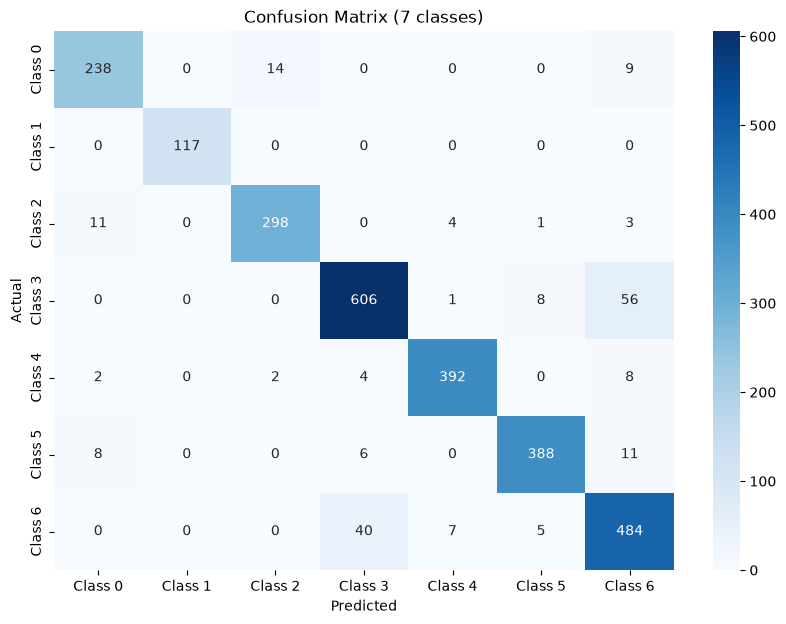

Accuracy: 0.9265515975027543
Precision (weighted): 0.9277901329477568
Recall (weighted): 0.9265515975027543
F1 (weighted): 0.9269362635447583


In [17]:
cm = confusion_matrix(y_test, y_pred)
labels = [f"Class {i}" for i in range(7)]
cm_df = pd.DataFrame(cm, index=[f"Actual {l}" for l in labels],
                         columns=[f"Predicted {l}" for l in labels])
print(cm_df)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels,
            yticklabels=labels)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix (7 classes)")
plt.show()

print("Accuracy:", accuracy_score(y_pred, y_test))
print("Precision (weighted):", precision_score(y_test, y_pred, average="weighted"))
print("Recall (weighted):", recall_score(y_test, y_pred, average="weighted"))
print("F1 (weighted):", f1_score(y_test, y_pred, average="weighted"))

In [25]:
cross_validate_model(model, X_train_sc, y_train, cv=10, bivariate = False)

Accuracy: 0.9239
Precision: 0.9245
Recall: 0.9239
F1 Score: 0.9240
Prediction time:  3.6645636558532715


{'fit_time': array([0.35625172, 0.34378147, 0.35744071, 0.34140587, 0.31311631,
        0.29573965, 0.28646708, 0.31571603, 0.32483768, 0.36177683]),
 'score_time': array([0.03272438, 0.03445101, 0.02595758, 0.04174662, 0.03569317,
        0.03378224, 0.0360949 , 0.03914857, 0.03341913, 0.02944636]),
 'test_accuracy': array([0.9164371 , 0.92929293, 0.92470156, 0.93204775, 0.91460055,
        0.92194674, 0.92837466, 0.92194674, 0.92095588, 0.92830882]),
 'test_precision': array([0.91783883, 0.93084033, 0.92544021, 0.93208038, 0.91453862,
        0.92208038, 0.92846311, 0.9223469 , 0.92313605, 0.92851079]),
 'test_recall': array([0.9164371 , 0.92929293, 0.92470156, 0.93204775, 0.91460055,
        0.92194674, 0.92837466, 0.92194674, 0.92095588, 0.92830882]),
 'test_f1': array([0.91681409, 0.92972706, 0.92492631, 0.93189716, 0.91421738,
        0.92191482, 0.92836906, 0.92196367, 0.92144307, 0.9282756 ])}

In [26]:
best_model, best_params = hyperparameterTuning(X_train_sc, y_train, cv=5, bivariate = True)

Best parameters: {'C': 10, 'l1_ratio': 0, 'max_iter': 1000, 'solver': 'lbfgs'}
Best cross-validation accuracy: 0.9247
Best cross-validation precision: 0.9379
Best cross-validation recall: 0.9351
Best cross-validation F1 Score: 0.9363
Time for Hypertuning:  26.671247482299805


----------------------------------------------------------------------------------------------
-------------------------------------- INPUT PERTUBATION -------------------------------------
----------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------
------------------------------------- OUTPUT PERTUBATION -------------------------------------
----------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------
------------------------------------ INTERNAL PERTUBATION ------------------------------------
----------------------------------------------------------------------------------------------